# Лабораторная работа 2
## Метод главных компонент (PCA) и k-ближайших соседей (kNN) на MNIST

В этой работе я:

1. загружаю изображения рукописных цифр MNIST;
2. реализую PCA самостоятельно через SVD;
3. реализую классификатор kNN самостоятельно;
4. сравниваю свои реализации с `scikit-learn`;
5. исследую влияние числа компонент PCA и числа соседей `k`;
6. измеряю точность и время работы;
7. строю итоговую тепловую карту.

Все основные действия снабжены подробными комментариями. Первая кодовая ячейка устанавливает отсутствующие библиотеки в текущее ядро VS Code.


## Важная настройка для запуска

MNIST содержит 70 000 изображений, а полный перебор расстояний в kNN может быть медленным на обычном компьютере. Поэтому ниже данные скачиваются полностью, но для экспериментов используется случайная стратифицированная выборка из `WORKING_SAMPLES` изображений.

Параметр можно увеличить, если компьютер работает быстро. Для первого запуска лучше оставить значение `5000`: этого достаточно, чтобы увидеть закономерности и избежать зависания ноутбука.


In [1]:
# Подключаю модуль, который умеет проверять наличие Python-пакетов.
import importlib.util
# Подключаю sys, чтобы установка выполнялась именно в Python текущего ядра VS Code.
import sys
# Подключаю subprocess для запуска pip из текущего интерпретатора Python.
import subprocess

# Создаю словарь: имя модуля -> имя пакета для установки.
required_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
}
# Создаю список только для отсутствующих пакетов.
missing_packages = []
# Проверяю каждый необходимый модуль.
for module_name, package_name in required_packages.items():
    # Если модуль не найден, добавляю соответствующий пакет в список установки.
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(package_name)

# Устанавливаю только отсутствующие библиотеки и не трогаю уже рабочее окружение.
if missing_packages:
    print("Устанавливаю библиотеки:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing_packages])
    print("Установка завершена.")
# Если всё уже установлено, сообщаю об этом.
else:
    print("Все необходимые библиотеки уже установлены.")


Устанавливаю библиотеки: scikit-learn, seaborn
Установка завершена.


In [2]:
# Подключаю NumPy для массивов, матриц и линейной алгебры.
import numpy as np
# Подключаю Matplotlib для изображений и графиков.
import matplotlib.pyplot as plt
# Подключаю Seaborn для красивой тепловой карты.
import seaborn as sns
# Подключаю стандартные модули для скачивания и распаковки MNIST.
import gzip
import struct
import time
from pathlib import Path
from urllib.request import urlretrieve
# Подключаю функции из scikit-learn только для проверки и сравнения.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.neighbors import KNeighborsClassifier

# Фиксирую генератор случайных чисел, чтобы результаты можно было повторить.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Ограничиваю размер рабочей выборки для быстрого запуска kNN.
WORKING_SAMPLES = 4000
# Создаю папку, в которую можно сохранять графики и результаты.
RESULTS_DIR = Path("attached_assets") / "mnist_pca_knn_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# Вывожу версии основных библиотек для проверки окружения.
print("NumPy:", np.__version__)
print("Рабочая папка для результатов:", RESULTS_DIR)


NumPy: 2.5.3
Рабочая папка для результатов: attached_assets\mnist_pca_knn_results


In [3]:
# Указываю официальный доступный URL с файлами MNIST.
MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
# Создаю папку для скачанных архивов MNIST.
MNIST_DIR = Path("MNIST-data")
MNIST_DIR.mkdir(parents=True, exist_ok=True)

# Описываю четыре файла: картинки и правильные ответы для train и test.
MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

# Скачиваю файл только тогда, когда его ещё нет на компьютере.
def download_mnist_file(filename):
    # Формирую локальный путь к нужному архиву.
    local_path = MNIST_DIR / filename
    # Проверяю, нужно ли скачивание.
    if not local_path.exists():
        print("Скачиваю", filename)
        urlretrieve(MNIST_URL + filename, local_path)
    # Возвращаю путь к готовому локальному файлу.
    return local_path

# Читаю архив с изображениями MNIST и превращаю его в массив.
def read_images(filename):
    # Открываю gzip-архив в бинарном режиме.
    with gzip.open(filename, "rb") as file:
        # Заголовок содержит код формата, число изображений, строки и столбцы.
        magic, count, rows, cols = struct.unpack(">IIII", file.read(16))
        # Проверяю код формата изображений.
        if magic != 2051:
            raise ValueError(f"Неожиданный код изображений: {magic}")
        # Читаю все пиксели и преобразую байты в числа от 0 до 255.
        data = np.frombuffer(file.read(), dtype=np.uint8)
        # Возвращаю форму (число изображений, 28, 28, 1).
        return data.reshape(count, rows, cols, 1)

# Читаю архив с метками цифр.
def read_labels(filename):
    # Открываю gzip-архив с метками.
    with gzip.open(filename, "rb") as file:
        # Заголовок содержит код формата и число меток.
        magic, count = struct.unpack(">II", file.read(8))
        # Проверяю код формата меток.
        if magic != 2049:
            raise ValueError(f"Неожиданный код меток: {magic}")
        # Возвращаю массив правильных цифр.
        return np.frombuffer(file.read(), dtype=np.uint8).reshape(count)

# Загружаю все четыре файла, при необходимости скачивая их.
train_images = read_images(download_mnist_file(MNIST_FILES["train_images"]))
train_labels = read_labels(download_mnist_file(MNIST_FILES["train_labels"]))
test_images = read_images(download_mnist_file(MNIST_FILES["test_images"]))
test_labels = read_labels(download_mnist_file(MNIST_FILES["test_labels"]))

# Показываю исходные размеры данных.
print("Обучающие изображения:", train_images.shape)
print("Обучающие метки:", train_labels.shape)
print("Тестовые изображения:", test_images.shape)
print("Тестовые метки:", test_labels.shape)


Скачиваю train-images-idx3-ubyte.gz
Скачиваю train-labels-idx1-ubyte.gz
Скачиваю t10k-images-idx3-ubyte.gz
Скачиваю t10k-labels-idx1-ubyte.gz
Обучающие изображения: (60000, 28, 28, 1)
Обучающие метки: (60000,)
Тестовые изображения: (10000, 28, 28, 1)
Тестовые метки: (10000,)


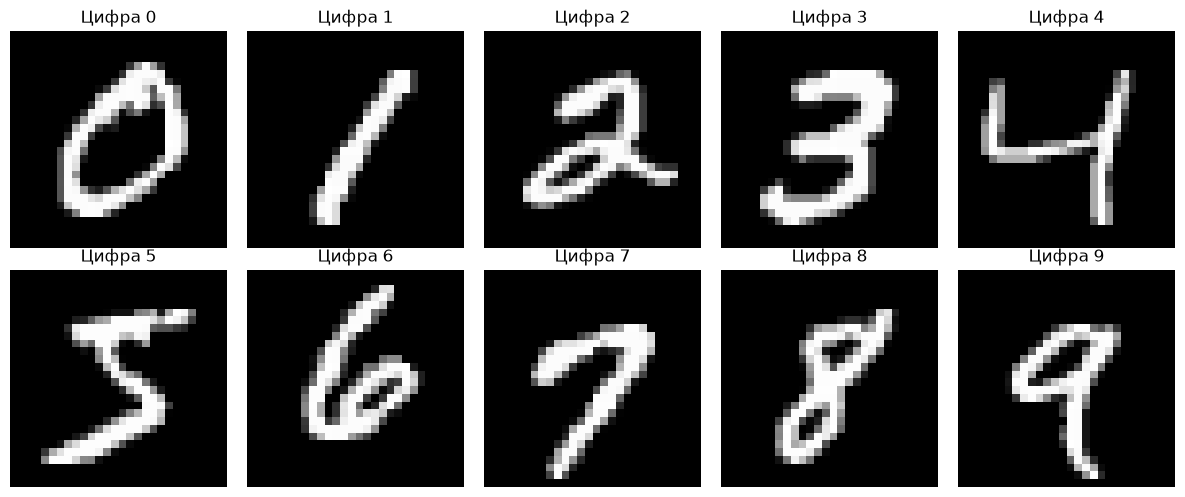

In [4]:
# Создаю сетку из десяти изображений.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
# Беру по одному примеру каждой цифры от 0 до 9.
for digit, axis in enumerate(axes.ravel()):
    # Находим первое изображение с нужной меткой.
    image_index = np.flatnonzero(train_labels == digit)[0]
    # Показываю картинку в оттенках серого.
    axis.imshow(train_images[image_index].reshape(28, 28), cmap="gray")
    # Подписываю цифру.
    axis.set_title(f"Цифра {digit}")
    # Убираю координатные оси, чтобы рисунок был чище.
    axis.axis("off")
# Автоматически выравниваю элементы рисунка.
plt.tight_layout()
# Сохраняю рисунок в папку результатов.
plt.savefig(RESULTS_DIR / "mnist_examples.png", dpi=150)
# Показываю рисунок.
plt.show()


In [5]:
# Не создаю огромную объединённую float32-матрицу всех 70 000 изображений.
# Вместо этого выбираю индексы рабочей подвыборки прямо из обучающей части.
all_train_indices = np.arange(train_images.shape[0])
# Сохраняю стратифицированное соотношение цифр в рабочей подвыборке.
selected_indices, _ = train_test_split(
    all_train_indices, train_size=WORKING_SAMPLES,
    stratify=train_labels, random_state=RANDOM_STATE
)
# Выбираю только нужные изображения и разворачиваю их в векторы из 784 пикселей.
X_work = train_images[selected_indices].reshape(len(selected_indices), -1)
# Перевожу пиксели в float32 и нормализую диапазон 0..255 к диапазону 0..1.
X_work = X_work.astype(np.float32) / 255.0
# Выбираю правильные ответы для тех же индексов.
y_work = train_labels[selected_indices].astype(np.int64)
# Разделяю рабочую выборку на обучение и проверку в пропорции 70/30.
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.30, stratify=y_work, random_state=RANDOM_STATE
)

# Вывожу формы и диапазон значений для контроля подготовки.
print("Рабочая подвыборка:", X_work.shape)
print("Обучающая часть:", X_train.shape)
print("Тестовая часть:", X_test.shape)
print("Диапазон пикселей:", X_work.min(), "..", X_work.max())
print("Классы:", np.unique(y_work))


Рабочая подвыборка: (4000, 784)
Обучающая часть: (2800, 784)
Тестовая часть: (1200, 784)
Диапазон пикселей: 0.0 .. 1.0
Классы: [0 1 2 3 4 5 6 7 8 9]


In [6]:
# Создаю собственную реализацию метода главных компонент.
class my_PCA:
    # Сохраняю желаемое число компонент.
    def __init__(self, n_components=None):
        # None означает сохранение всех доступных компонент.
        self.n_components = n_components
        # Эти атрибуты заполняются после fit.
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
        self.n_components_ = None

    # Обучаю PCA на матрице X размера (объекты, признаки).
    def fit(self, X):
        # Проверяю, что вход является двумерной матрицей.
        X = np.asarray(X, dtype=np.float32)
        if X.ndim != 2:
            raise ValueError("X должен иметь форму (число объектов, число признаков)")
        # Запоминаю среднее каждого признака для последующего transform.
        self.mean_ = np.mean(X, axis=0)
        # Центрирую данные: среднее каждого столбца становится равным нулю.
        X_centered = X - self.mean_
        # Выполняю SVD центрированной матрицы: X_centered = U @ S @ Vt.
        _, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
        # Число доступных компонент ограничено рангом матрицы.
        max_components = Vt.shape[0]
        # Если число компонент не задано, оставляю все доступные компоненты.
        if self.n_components is None:
            component_count = max_components
        else:
            # Преобразую параметр в обычное целое число.
            component_count = int(self.n_components)
            # Проверяю допустимый диапазон.
            if component_count < 1 or component_count > max_components:
                raise ValueError(f"n_components должен быть от 1 до {max_components}")
        # Собственные векторы ковариационной матрицы равны строкам Vt.
        self.components_ = Vt[:component_count]
        # Собственные значения ковариационной матрицы равны S^2/(n-1).
        self.explained_variance_ = (singular_values ** 2 / max(1, X.shape[0] - 1))[:component_count]
        # Считаю долю дисперсии каждой компоненты.
        total_variance = np.sum(singular_values ** 2 / max(1, X.shape[0] - 1))
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        # Запоминаю фактическое число сохранённых компонент.
        self.n_components_ = component_count
        # Возвращаю сам объект PCA, как это делает sklearn.
        return self

    # Перевожу новые данные в пространство главных компонент.
    def transform(self, X):
        # Проверяю, что PCA уже был обучен.
        if self.components_ is None:
            raise RuntimeError("Сначала нужно вызвать fit")
        # Центрирую новые объекты тем же средним, что использовалось при обучении.
        X_centered = np.asarray(X, dtype=np.float32) - self.mean_
        # Умножение на транспонированные компоненты даёт новые координаты.
        return X_centered @ self.components_.T

    # Обучаю PCA и сразу преобразую исходные данные.
    def fit_transform(self, X):
        # Сначала обучаю PCA, затем вызываю transform.
        return self.fit(X).transform(X)

    # Восстанавливаю приближённые исходные данные из координат PCA.
    def inverse_transform(self, X_transformed):
        # Возвращаю центрированные координаты обратно в исходное пространство.
        return np.asarray(X_transformed) @ self.components_ + self.mean_


In [7]:
# Обучаю собственный PCA на рабочей выборке.
pca_full = my_PCA()
Y_work = pca_full.fit_transform(X_work)

# Вывожу основные размеры результата.
print("Число компонент:", pca_full.n_components_)
print("Форма матрицы компонент:", pca_full.components_.shape)
print("Форма координат после PCA:", Y_work.shape)
# Считаю долю дисперсии первых 15 компонент.
variance_15 = np.sum(pca_full.explained_variance_ratio_[:15])
# Находжу минимальное число компонент для 95 процентов дисперсии.
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
components_for_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)
print(f"Доля дисперсии первых 15 компонент: {variance_15:.4f} ({variance_15:.2%})")
print(f"Компонент для 95% дисперсии: {components_for_95}")

# Проверяю приближённое восстановление через 30 компонент.
pca_30 = my_PCA(n_components=30)
Y_30 = pca_30.fit_transform(X_work)
X_reconstructed = pca_30.inverse_transform(Y_30)
# Считаю среднюю квадратичную ошибку восстановления.
reconstruction_mse = np.mean((X_work - X_reconstructed) ** 2)
print(f"MSE восстановления при 30 компонентах: {reconstruction_mse:.6f}")


Число компонент: 784
Форма матрицы компонент: (784, 784)
Форма координат после PCA: (4000, 784)
Доля дисперсии первых 15 компонент: 0.5816 (58.16%)
Компонент для 95% дисперсии: 148
MSE восстановления при 30 компонентах: 0.018021


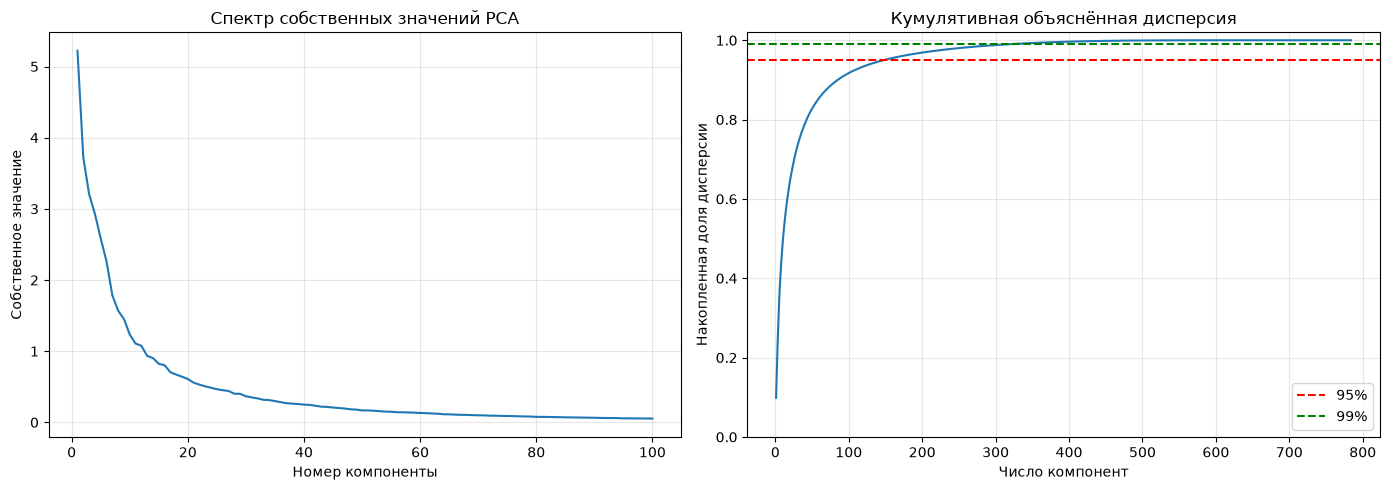

In [8]:
# Создаю область с двумя графиками.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Строю график собственных значений первых 100 компонент.
show_count = min(100, len(pca_full.explained_variance_))
axes[0].plot(np.arange(1, show_count + 1), pca_full.explained_variance_[:show_count])
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].set_title("Спектр собственных значений PCA")
axes[0].grid(True, alpha=0.3)
# Строю график накопленной доли объяснённой дисперсии.
axes[1].plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance)
# Отмечаю уровни 95 и 99 процентов.
axes[1].axhline(0.95, color="red", linestyle="--", label="95%")
axes[1].axhline(0.99, color="green", linestyle="--", label="99%")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная доля дисперсии")
axes[1].set_title("Кумулятивная объяснённая дисперсия")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Сохраняю и показываю рисунок.
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_variance.png", dpi=150)
plt.show()


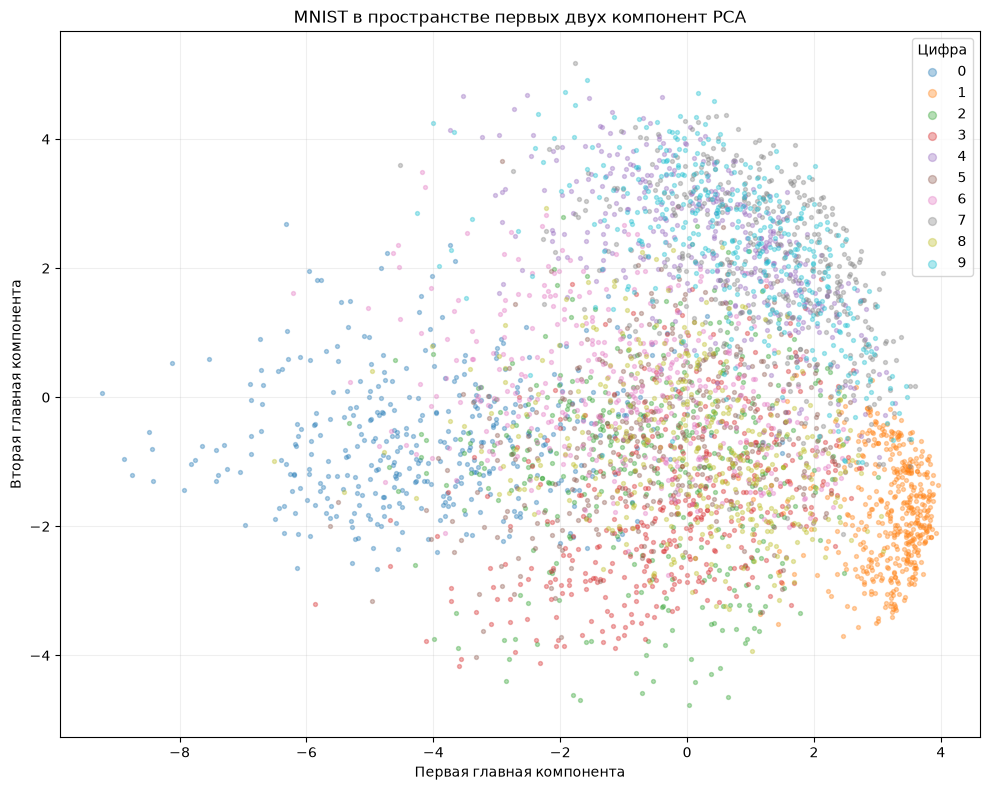

In [9]:
# Проецирую рабочие данные только на первые две компоненты.
pca_2d = my_PCA(n_components=2)
Y_2d = pca_2d.fit_transform(X_work)
# Создаю рисунок для десяти классов цифр.
plt.figure(figsize=(10, 8))
# Рисую точки каждого класса отдельно, чтобы увидеть группы.
for digit in range(10):
    # Формирую маску строк, принадлежащих текущей цифре.
    mask = y_work == digit
    # Показываю точки текущего класса полупрозрачным цветом.
    plt.scatter(Y_2d[mask, 0], Y_2d[mask, 1], s=8, alpha=0.35, label=str(digit))
# Подписываю оси и легенду.
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("MNIST в пространстве первых двух компонент PCA")
plt.legend(title="Цифра", markerscale=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_2d.png", dpi=150)
plt.show()


In [10]:
# Создаю собственную реализацию k ближайших соседей.
class my_kNN:
    # Запоминаю число соседей.
    def __init__(self, n_neighbors=5):
        # Проверяю, что число соседей положительное.
        if int(n_neighbors) < 1:
            raise ValueError("n_neighbors должен быть положительным")
        # Сохраняю параметр классификатора.
        self.n_neighbors = int(n_neighbors)
        # Эти поля заполняются при вызове fit.
        self.X_train = None
        self.y_train = None

    # Обучение kNN состоит в запоминании обучающей выборки.
    def fit(self, X, y):
        # Сохраняю признаки в формате float32 для меньшего расхода памяти.
        self.X_train = np.asarray(X, dtype=np.float32)
        # Сохраняю метки классов.
        self.y_train = np.asarray(y, dtype=np.int64)
        # Проверяю согласованность числа объектов и меток.
        if self.X_train.shape[0] != self.y_train.shape[0]:
            raise ValueError("Число объектов и меток должно совпадать")
        # Проверяю, что k не больше обучающей выборки.
        if self.n_neighbors > self.X_train.shape[0]:
            raise ValueError("n_neighbors не может быть больше числа обучающих объектов")
        # Возвращаю сам классификатор.
        return self

    # Нахожу индексы ближайших соседей сразу для нескольких объектов.
    def _nearest_indices(self, X, max_neighbors):
        # Проверяю, что модель уже обучена.
        if self.X_train is None:
            raise RuntimeError("Сначала нужно вызвать fit")
        # Привожу вход к двумерной матрице float32.
        X = np.asarray(X, dtype=np.float32)
        # Не создаю огромную матрицу расстояний целиком, а обрабатываю блоки.
        batch_size = 256
        # Создаю список блоков с индексами ближайших соседей.
        all_neighbor_indices = []
        # Обрабатываю тестовые объекты небольшими блоками.
        for start in range(0, X.shape[0], batch_size):
            # Определяю конец текущего блока.
            stop = min(start + batch_size, X.shape[0])
            # Выбираю текущий блок тестовых объектов.
            batch = X[start:stop]
            # Считаю квадрат нормы каждого объекта тестового блока.
            batch_norm = np.sum(batch * batch, axis=1, keepdims=True)
            # Считаю квадрат нормы каждого обучающего объекта.
            train_norm = np.sum(self.X_train * self.X_train, axis=1)[None, :]
            # Использую формулу ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a*b.
            distances = batch_norm + train_norm - 2.0 * (batch @ self.X_train.T)
            # Из-за ошибок вычислений исправляю очень маленькие отрицательные значения.
            distances = np.maximum(distances, 0.0)
            # Беру только max_neighbors самых близких индексов без полной сортировки.
            nearest = np.argpartition(distances, max_neighbors - 1, axis=1)[:, :max_neighbors]
            # Сохраняю индексы для текущего блока.
            all_neighbor_indices.append(nearest)
        # Объединяю результаты блоков в одну матрицу.
        return np.vstack(all_neighbor_indices)

    # Возвращаю самый частый класс среди переданных меток.
    @staticmethod
    def _majority_vote(labels):
        # Подсчитываю количество каждого класса и выбираю самый частый.
        return np.bincount(labels, minlength=10).argmax()

    # Предсказываю классы для новых объектов.
    def predict(self, X):
        # Нахожу k ближайших соседей.
        neighbors = self._nearest_indices(X, self.n_neighbors)
        # Для каждой строки выполняю голосование большинства.
        return np.array([self._majority_vote(self.y_train[row]) for row in neighbors])

    # Эффективно считаю предсказания сразу для нескольких значений k.
    def predict_for_k_values(self, X, k_values):
        # Преобразую значения k в отсортированный список целых чисел.
        k_values = sorted({int(k) for k in k_values})
        # Для всех значений k достаточно найти соседей до максимального k один раз.
        neighbors = self._nearest_indices(X, max(k_values))
        # Создаю словарь для результатов разных k.
        predictions = {}
        # Для каждого k считаю голоса только первых k соседей.
        for k in k_values:
            predictions[k] = np.array([self._majority_vote(self.y_train[row[:k]]) for row in neighbors])
        # Возвращаю словарь k -> предсказания.
        return predictions


In [11]:
# Обучаю собственный kNN с пятью соседями.
my_knn = my_kNN(n_neighbors=5)
my_knn.fit(X_train, y_train)
# Засекаю время собственного предсказания.
start_time = time.perf_counter()
y_pred_my = my_knn.predict(X_test)
my_time = time.perf_counter() - start_time
# Считаю точность своего классификатора.
accuracy_my = accuracy_score(y_test, y_pred_my)
print(f"Точность my_kNN: {accuracy_my:.4f}")
print(f"Время предсказания my_kNN: {my_time:.2f} с")

# Обучаю стандартный kNN из scikit-learn на тех же данных.
sk_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
sk_knn.fit(X_train, y_train)
# Получаю предсказания стандартного классификатора.
y_pred_sk = sk_knn.predict(X_test)
# Считаю точность sklearn.
accuracy_sk = accuracy_score(y_test, y_pred_sk)
print(f"Точность sklearn kNN: {accuracy_sk:.4f}")
print(f"Разница точности: {abs(accuracy_my - accuracy_sk):.4f}")


Точность my_kNN: 0.9117
Время предсказания my_kNN: 1.07 с
Точность sklearn kNN: 0.9117
Разница точности: 0.0000


Лучшее k в эксперименте: 1
Лучшая точность: 0.9158


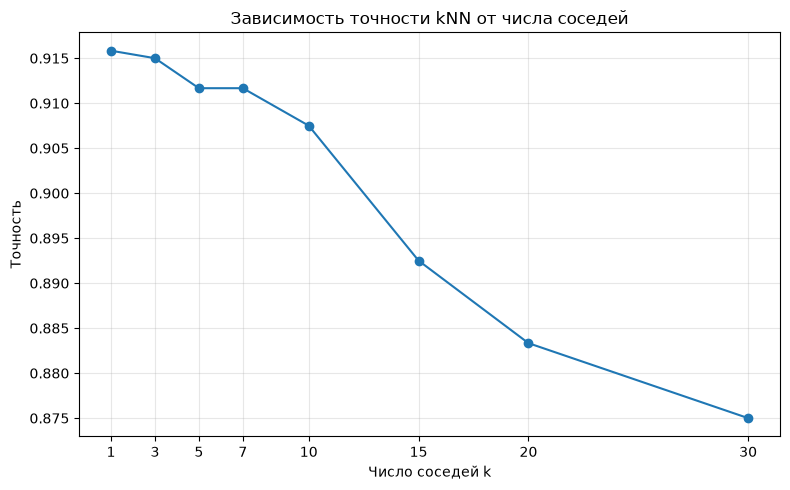

In [12]:
# Задаю значения k из задания.
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
# Получаю все предсказания одним вычислением расстояний.
k_predictions = my_knn.predict_for_k_values(X_test, k_values)
# Считаю точность для каждого k.
k_accuracies = [accuracy_score(y_test, k_predictions[k]) for k in k_values]
# Нахожу лучшее значение k.
best_k_index = int(np.argmax(k_accuracies))
best_k = k_values[best_k_index]
print(f"Лучшее k в эксперименте: {best_k}")
print(f"Лучшая точность: {k_accuracies[best_k_index]:.4f}")

# Строю график точности от числа соседей.
plt.figure(figsize=(8, 5))
plt.plot(k_values, k_accuracies, "o-")
plt.xlabel("Число соседей k")
plt.ylabel("Точность")
plt.title("Зависимость точности kNN от числа соседей")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_accuracy_by_k.png", dpi=150)
plt.show()


Лучшее число компонент: 30
Лучшая точность PCA + kNN: 0.9367


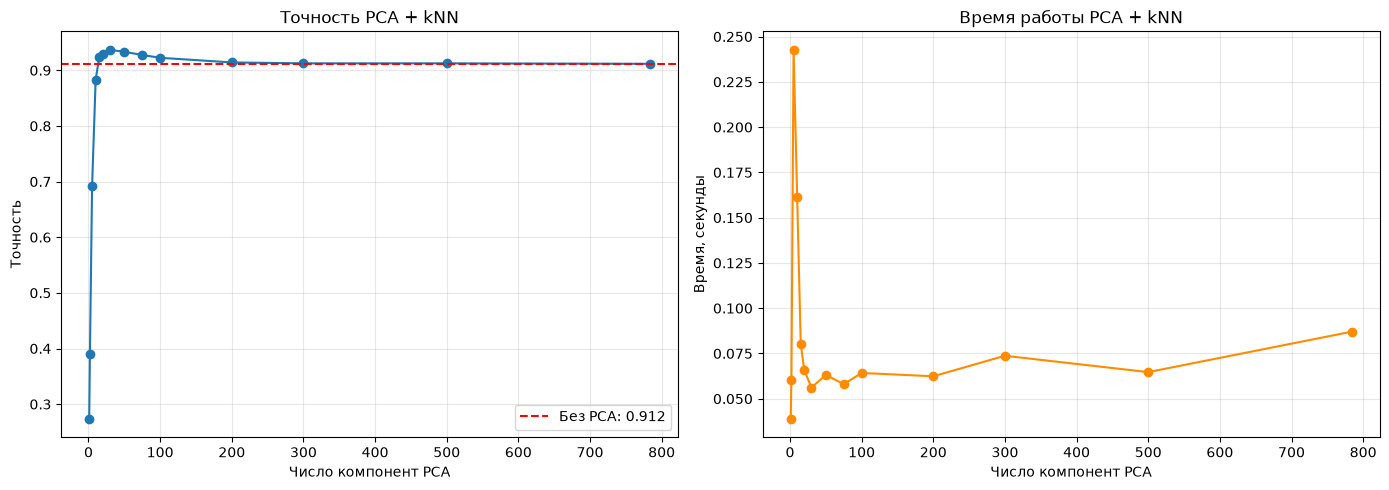

In [13]:
# Обучаю один PCA на обучающей части, чтобы не использовать тестовые метки при обучении.
pca_for_knn = my_PCA()
pca_for_knn.fit(X_train)
# Преобразую train и test в одно общее пространство из всех доступных компонент.
X_train_pca_all = pca_for_knn.transform(X_train)
X_test_pca_all = pca_for_knn.transform(X_test)
# Задаю числа компонент для основного эксперимента.
n_components_list = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100, 200, 300, 500, 784]
# Оставляю только допустимые значения для конкретного набора данных.
n_components_list = [n for n in n_components_list if n <= X_train_pca_all.shape[1]]
# Создаю списки для точностей и времени.
pca_accuracies = []
pca_times = []

# Перебираю варианты количества главных компонент.
for n_components in n_components_list:
    # Оставляю первые n компонент у train.
    X_train_reduced = X_train_pca_all[:, :n_components]
    # Оставляю первые n компонент у test.
    X_test_reduced = X_test_pca_all[:, :n_components]
    # Создаю kNN с пятью соседями.
    model = my_kNN(n_neighbors=5)
    # Засекаю полное время fit + predict.
    start_time = time.perf_counter()
    model.fit(X_train_reduced, y_train)
    predictions = model.predict(X_test_reduced)
    elapsed = time.perf_counter() - start_time
    # Сохраняю точность и время.
    pca_accuracies.append(accuracy_score(y_test, predictions))
    pca_times.append(elapsed)

# Нахожу лучшее число компонент.
best_pca_index = int(np.argmax(pca_accuracies))
best_components = n_components_list[best_pca_index]
print(f"Лучшее число компонент: {best_components}")
print(f"Лучшая точность PCA + kNN: {pca_accuracies[best_pca_index]:.4f}")

# Строю график точности в зависимости от числа компонент.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(n_components_list, pca_accuracies, "o-")
axes[0].axhline(accuracy_my, color="red", linestyle="--", label=f"Без PCA: {accuracy_my:.3f}")
axes[0].set_xlabel("Число компонент PCA")
axes[0].set_ylabel("Точность")
axes[0].set_title("Точность PCA + kNN")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Строю график времени работы.
axes[1].plot(n_components_list, pca_times, "o-", color="darkorange")
axes[1].set_xlabel("Число компонент PCA")
axes[1].set_ylabel("Время, секунды")
axes[1].set_title("Время работы PCA + kNN")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_knn_accuracy_time.png", dpi=150)
plt.show()


Лучшая комбинация: PCA=30, k=1
Максимальная точность: 0.9392
Худшая точность: 0.6658


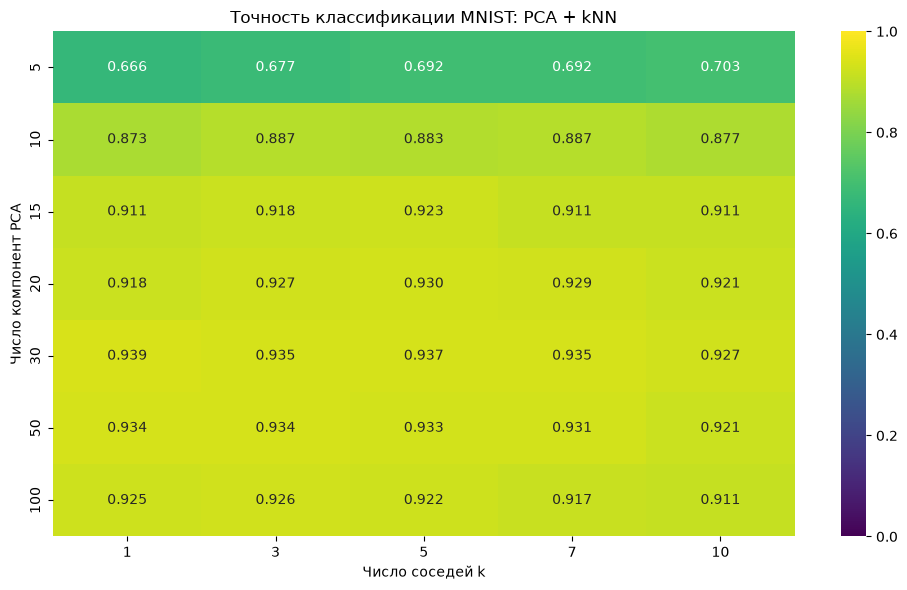

In [14]:
# Задаю параметры для итогового перебора из задания.
n_components_grid = [5, 10, 15, 20, 30, 50, 100]
k_grid = [1, 3, 5, 7, 10]
# Создаю пустую матрицу: строки соответствуют PCA, столбцы — k.
accuracy_matrix = np.zeros((len(n_components_grid), len(k_grid)))

# Перебираю число компонент PCA.
for row, n_components in enumerate(n_components_grid):
    # Выбираю первые компоненты для train и test.
    X_train_reduced = X_train_pca_all[:, :n_components]
    X_test_reduced = X_test_pca_all[:, :n_components]
    # Обучаю один объект kNN и получаю соседей до максимального k.
    grid_knn = my_kNN(n_neighbors=max(k_grid))
    grid_knn.fit(X_train_reduced, y_train)
    grid_predictions = grid_knn.predict_for_k_values(X_test_reduced, k_grid)
    # Заполняю строку точностями для разных k.
    for column, k in enumerate(k_grid):
        accuracy_matrix[row, column] = accuracy_score(y_test, grid_predictions[k])

# Находжу позицию лучшей комбинации.
best_row, best_column = np.unravel_index(np.argmax(accuracy_matrix), accuracy_matrix.shape)
print(f"Лучшая комбинация: PCA={n_components_grid[best_row]}, k={k_grid[best_column]}")
print(f"Максимальная точность: {accuracy_matrix[best_row, best_column]:.4f}")
print(f"Худшая точность: {accuracy_matrix.min():.4f}")

# Рисую heatmap с подписями точности в каждой ячейке.
plt.figure(figsize=(10, 6))
sns.heatmap(
    accuracy_matrix, annot=True, fmt=".3f", cmap="viridis",
    xticklabels=k_grid, yticklabels=n_components_grid,
    vmin=0, vmax=1
)
plt.xlabel("Число соседей k")
plt.ylabel("Число компонент PCA")
plt.title("Точность классификации MNIST: PCA + kNN")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_knn_heatmap.png", dpi=150)
plt.show()


In [15]:
# Проверяю, что все ключевые результаты имеют правильные формы.
assert X_work.shape[1] == 784
assert Y_work.shape[1] == pca_full.n_components_
assert y_pred_my.shape == y_test.shape
assert accuracy_matrix.shape == (len(n_components_grid), len(k_grid))
assert np.all((np.array(pca_accuracies) >= 0) & (np.array(pca_accuracies) <= 1))
# Проверяю, что первая компонента объясняет не меньше дисперсии, чем следующая.
assert pca_full.explained_variance_[0] >= pca_full.explained_variance_[1]
print("Все автоматические проверки пройдены.")
print("Результаты сохранены в:", RESULTS_DIR)


Все автоматические проверки пройдены.
Результаты сохранены в: attached_assets\mnist_pca_knn_results


## Итоговые выводы

1. **PCA** уменьшает число признаков, заменяя исходные пиксели новыми взаимно перпендикулярными направлениями — главными компонентами.
2. Первые компоненты содержат наибольшую дисперсию, поэтому обычно хранят основную структуру цифр.
3. **kNN** не строит сложную модель: он запоминает обучающие объекты и для нового объекта выбирает наиболее частый класс среди ближайших соседей.
4. Малое значение `k` чувствительно к шуму, а слишком большое значение смешивает разные классы. Поэтому качество обычно имеет максимум при некотором среднем `k`.
5. PCA уменьшает размерность и ускоряет вычисление расстояний. При слишком малом числе компонент часть информации о форме цифр теряется, поэтому точность падает.
6. Оптимальное число компонент выбирается по компромиссу между точностью и временем работы, а не обязательно равно 784.
7. В этой работе собственные реализации проверены сравнением со `scikit-learn`, а результаты зависят от размера рабочей подвыборки и конкретного разбиения данных.


> PCA центрирует данные и с помощью SVD находит направления максимальной дисперсии. Мы оставляем первые компоненты и тем самым уменьшаем размерность изображений с 784 признаков. kNN классифицирует цифру по большинству среди ближайших объектов. При уменьшении числа компонент kNN работает быстрее, но при слишком сильном уменьшении теряется информация и падает точность.
